In [1]:
from cobolt.utils import SingleData, MultiomicDataset
from cobolt.model import Cobolt
import os
import gc
import numpy as np
import pandas as pd
import scipy.sparse as sps
from pathlib import Path, PurePath
import scanpy as sc
import h5py
import scipy.io as sio
import warnings
from muon import atac as ac
import seaborn as sns

from os.path import join
import matplotlib.pyplot as plt

/home/xuhua/xuhua_disco/miniforge3/envs/Squidpy/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_col2cat(ad, cols=[]):
    for col in cols:
        ad.obs[col] = ad.obs[col].astype('category')

def unify_colors(queries, color_key, ref_color_dict):
    for q in queries:
        q.obs[color_key] = q.obs[color_key].astype('category')
        q.uns[f'{color_key}_colors'] = [ref_color_dict[_] for _ in q.obs[color_key].cat.categories]
    return queries

def get_umap(ad, use_reps=[]):
    for use_rep in use_reps:
        umap_add_key = f'{use_rep}_umap'
        sc.pp.neighbors(ad, use_rep=use_rep, n_neighbors=15)
        sc.tl.umap(ad)
        ad.obsm[umap_add_key] = ad.obsm['X_umap']
    return ad

def wrap_warn_plot(adata, basis, color, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        sc.pl.embedding(adata, basis=basis, color=color, **kwargs)

def wrap_warn_comp_plot(ads, basis, colors, figw=5, figh=4, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, color in enumerate(colors):
            _, axes = plt.subplots(1, len(ads), figsize=(figw*len(ads), figh))
            for j, ad in enumerate(ads):
                sc.pl.embedding(ad, basis=basis, color=color, ax=axes[j], show=False, **kwargs)
            plt.show()

In [3]:
def split_ob(ads, ad_ref, ob='obs', key='emb2'):
    len_ads = [_.n_obs for _ in ads]
    if ob=='obsm':
        split_obsms = np.split(ad_ref.obsm[key], np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obsms):
            ad.obsm[key] = v
    else:
        split_obs = np.split(ad_ref.obs[key].to_list(), np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obs):
            ad.obs[key] = v
    
def subset_ad(ad, subset_index):
    ad = ad[subset_index].copy()
    return ad

def set_spatial(ad):
    ad.obsm['spatial'] = ad.obs[['array_row', 'array_col']].values
    ad.obsm['spatial'] = ad.obsm['spatial'][:, ::-1]
    ad.obsm['spatial'][:, 1] = -1 * ad.obsm['spatial'][:, 1]
    return ad

import gzip
from scipy.io import mmread
def load_data(_dir):
    feat_names = pd.read_csv(join(_dir, 'features.tsv.gz'), compression='gzip', sep='\t', header=None)
    barcodes   = pd.read_csv(join(_dir, 'barcodes.tsv.gz'), compression='gzip', sep='\t', header=None)

    with gzip.open(join(_dir, 'matrix.mtx.gz'), 'rb') as gzipped_file:
        mat = mmread(gzipped_file)

    ad = sc.AnnData(sps.csr_matrix(mat.T))
    ad.obs_names = barcodes[0].values
    ad.var_names = feat_names[1].values
    ad.var['id'] = feat_names[0].values
    ad.var['type'] = feat_names[2].values
    return ad

In [4]:
data_dir = '../../../data/raw/Lymph_node/LN-2024-new/outs'

ad3 = load_data(join(data_dir, 'filtered_feature_bc_matrix'))
ad3_rna = ad3[:, ad3.var['type']=='Gene Expression'].copy()
ad3_adt = ad3[:, ad3.var['type']=='Antibody Capture'].copy()
load_spatial(join(data_dir, 'spatial'), ad3_rna)
load_spatial(join(data_dir, 'spatial'), ad3_adt)

ad3_rna.obs['src'] = ad3_adt.obs['src'] = ['s3']*ad3_rna.n_obs
ad3_rna.obs_names = [f's3-{x}' for x in ad3_rna.obs_names]
ad3_adt.obs_names = [f's3-{x}' for x in ad3_adt.obs_names]

ad3_rna.var_names_make_unique()
ad3_adt.var_names_make_unique()

data_dir = '../../../data/raw/Lymph_node/lymp_tonsil_ramen'

ad_a1_rna = sc.read_h5ad(join(data_dir, 'lymph_A1/adata_RNA.h5ad'))
ad_a1_adt = sc.read_h5ad(join(data_dir, 'lymph_A1/adata_ADT.h5ad'))
meta1 = pd.read_csv(join(data_dir, 'lymph_A1/A1_LN_cloupe_Kwoh.csv'), index_col=0) 
ad_a1_rna.obs['lab'] = meta1.loc[ad_a1_rna.obs_names, 'manual'].to_list()
ad_a1_adt.obs['lab'] = meta1.loc[ad_a1_adt.obs_names, 'manual'].to_list()
ad_a1_rna.obs['src'] = ad_a1_adt.obs['src'] = ['s1'] * ad_a1_rna.n_obs
ad_a1_rna.obs_names = [f's1-{x}' for x in ad_a1_rna.obs_names]
ad_a1_adt.obs_names = [f's1-{x}' for x in ad_a1_adt.obs_names]
ad_a1_rna.var_names_make_unique()
ad_a1_adt.var_names_make_unique()

ad_d1_rna = sc.read_h5ad(join(data_dir, 'lymph_D1/adata_RNA.h5ad'))
ad_d1_adt = sc.read_h5ad(join(data_dir, 'lymph_D1/adata_ADT.h5ad'))
meta2 = pd.read_csv(join(data_dir, 'lymph_D1/D1_LN_cloupe_Kwoh.csv'), index_col=0) 
ad_d1_rna.obs['lab'] = meta2.loc[ad_d1_rna.obs_names, 'manual'].to_list()
ad_d1_adt.obs['lab'] = meta2.loc[ad_d1_adt.obs_names, 'manual'].to_list()
ad_d1_rna.obs['src'] = ad_d1_adt.obs['src'] = ['s2'] * ad_d1_rna.n_obs
ad_d1_rna.obs_names = [f's2-{x}' for x in ad_d1_rna.obs_names]
ad_d1_adt.obs_names = [f's2-{x}' for x in ad_d1_adt.obs_names]
ad_d1_rna.var_names_make_unique()
ad_d1_adt.var_names_make_unique()

/home/xuhua/xuhua_disco/miniforge3/envs/Squidpy/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/xuhua/xuhua_disco/miniforge3/envs/Squidpy/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/xuhua/xuhua_disco/miniforge3/envs/Squidpy/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/xuhua/xuhua_disco/miniforge3/envs/Squidpy/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/xuhua/xuhua_disco/miniforge3/envs/

In [5]:
ad_rna_all = sc.concat([ad_a1_rna, ad_d1_rna, ad3_rna])
ad_adt_all = sc.concat([ad_a1_adt, ad_d1_adt, ad3_adt])

sc.pp.highly_variable_genes(ad_rna_all, flavor='seurat_v3', n_top_genes=10000, batch_key='src')
hvg_names = ad_rna_all.var.query('highly_variable').index.to_numpy()

In [6]:
hvp_names = ad_adt_all.var_names.to_list()

In [8]:
mult_rna_count = ad_a1_rna[:, hvg_names].X.astype(np.float32)
mult_adt_count = ad_a1_adt[:, hvp_names].X.astype(np.float32)
mult_rna_count = sps.csr_matrix(mult_rna_count)  
mult_adt_count = sps.csr_matrix(mult_adt_count)   # slowly, fuck, fuck, fuck
mult_barcode = ad_a1_rna.obs_names.to_numpy()

rna_feature = np.array(hvg_names)
adt_feature = np.array(hvp_names)

In [9]:
mult_rna = SingleData("GeneExpr", "Multiome", rna_feature, mult_rna_count, mult_barcode)
mult_adt = SingleData("Protein", "Multiome", adt_feature, mult_adt_count, mult_barcode)

In [10]:
single_rna_count = ad_d1_rna[:, hvg_names].X.astype(np.float32)
single_adt_count = ad3_adt[:, hvp_names].X.astype(np.float32)
single_rna_count = sps.csr_matrix(single_rna_count)
single_adt_count = sps.csr_matrix(single_adt_count)
single_rna_barcode = ad_d1_rna.obs_names.to_numpy()
single_adt_barcode = ad3_adt.obs_names.to_numpy()

In [11]:
single_rna = SingleData("GeneExpr", "Single-GEX", rna_feature, single_rna_count, single_rna_barcode)
single_adt = SingleData("Protein", "Single-Protein", adt_feature, single_adt_count, single_adt_barcode)

In [12]:
multi_dt = MultiomicDataset.from_singledata(
    single_rna, single_adt, mult_adt, mult_rna)
print(multi_dt)

A MultiomicDataset object with 2 omics:
- GeneExpr: 10000 features, 6843 cells, 2 batches.
- Protein: 31 features, 6892 cells, 2 batches.
Joint cells:
- GeneExpr, Protein: 3484 cells.


### Training

In [13]:
model = Cobolt(dataset=multi_dt, lr=0.001, n_latent=10, batch_size=128) 
model.train(num_epochs=100)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:06<00:00,  4.27s/it]


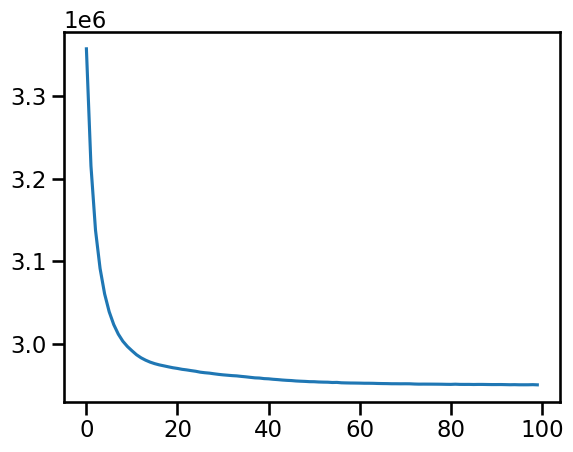

In [14]:
plt.plot(model.history['loss'])

In [15]:
model.calc_all_latent()

latent = model.get_all_latent()

In [16]:
if True:
    latent_barcode = np.array([_.split('~')[1] for _ in latent[1]])
    df_latent = pd.DataFrame(latent[0], index=latent_barcode)
    df_latent.to_csv('./outputs/lymph/res.csv')

else:
    df_latent = pd.read_csv('./outputs/lymph/res.csv', index_col=0)
    df_latent.index = df_latent.index.astype('str')

In [17]:
ad_a1_adt.obsm['X_emb'] = df_latent.loc[ad_a1_adt.obs_names, :].values
ad_d1_adt.obsm['X_emb'] = df_latent.loc[ad_d1_adt.obs_names, :].values
ad3_adt.obsm['X_emb'] = df_latent.loc[ad3_adt.obs_names, :].values

In [18]:
ad_mosaic = sc.concat([ad_a1_adt, ad_d1_adt, ad3_adt])
ad_mosaic = get_umap(ad_mosaic, ['X_emb'])

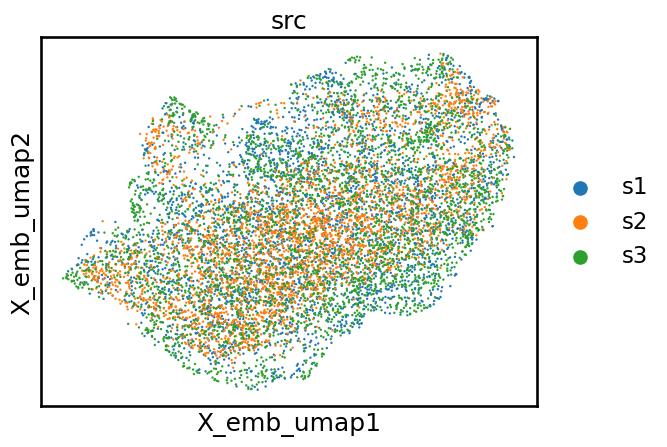

In [19]:
# # plot
wrap_warn_plot(ad_mosaic, 'X_emb_umap', ['src'])

In [30]:
fig_dir = f'../../../results/embeddings/Cobolt/Lymph-S1-S2-S3'
os.makedirs(fig_dir, exist_ok=True)

df = pd.DataFrame(ad_mosaic.obsm['X_emb'], index=ad_mosaic.obs_names)
df.to_csv(join(fig_dir, 'df_emb.csv'))

In [31]:
1

1